In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from rdkit import Chem
from rdkit.Chem import Draw

# Aggregation States

A solution is a homogeneous mixture where a solute (i.e. drug molecules) is dispersed in a solvent (e.g., water). Aggregation states refer to how solute particles group together or disperse in the solvent. This affects solubility and bioavailability, and is another source of alteoric uncertainty.

Aggregation can range from individual molecules (monomers) to clusters (aggregates) or larger particles, and it's affected by a wide range of conditions including solvent concentration, temperature, and molecular properties.

1. **Monomers (True Solution)**: Individual molecules (<1 nm) below CMC.  
   *Example: Dissolved ibuprofen.*

2. **Micelles (Colloidal Dispersion)**: Clusters (1 nm–1 μm) above CMC.  
   *Example: Ibuprofen micelles in water.*

3. **Suspensions**: Large clumps (>1 μm) that settle out of solution.

In AQSolDB, micelles can increase apparent solubility but may also trap drugs, affecting their delivery.

### Critical Micelle Concentration (CMC)

CMC is the concentration above which amphiphilic molecules (with both hydrophobic and hydrophilic parts) form micelles instead of remaining as individual **monomers**. 

- Below CMC: molecules are dispersed as monomers 
- Above CMC: molecules cluster together to minimise the exposure of their hydrophobic regions to water.


### Drivers of aggregation

- **Hydrophobic Effect**: Drives micelle formation as hydrophobic parts of molecules avoid water, reducing the system's free energy. This can be described by the equation: $\Delta G = RT \ln(\text{CMC})$,  
  where *R* is the gas constant, *T* is temperature, and *CMC* is in *mol/L*.

- **Lennard-Jones Potential**: Models the attraction (van der Waals) and repulsion between molecules:  
  $$ V(r) = 4\varepsilon \left[ \left(\frac{\sigma}{r}\right)^{12} - \left(\frac{\sigma}{r}\right)^6 \right] $$
  - $r$: Distance between molecules  
  - $\epsilon$: Depth of the energy well (strength of attraction)  
  - $\sigma$: Distance at which the potential is zero

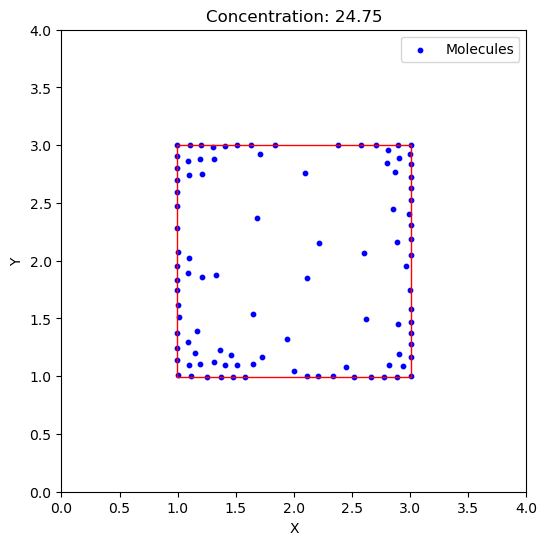

In [31]:
np.random.seed(42)
n_particles = 100

# Reduce container to increase conc.
initial_box_size = 4.0
final_box_size = 2.0
positions = np.random.rand(n_particles, 2) * initial_box_size
velocity = np.zeros((n_particles, 2))
epsilon = 0.02
sigma = 0.1
dt = 0.05
damping = 0.85
wall_damp = 0.95
brownian_strength = 1.0

# Lennard-Jones force
def lennard_jones_force(r, epsilon, sigma):
    r = max(r, 1e-6)
    term = sigma / r
    return np.clip(24 * epsilon * (2 * term**13 - term**7) / r, -5, 5)

fig, ax = plt.subplots(figsize=(6, 6))
scat = ax.scatter(positions[:, 0], positions[:, 1], s=10, color='blue', label='Molecules')
ax.set_xlim(0, initial_box_size)
ax.set_ylim(0, initial_box_size)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Micelle Formation with Increasing Concentration')
ax.legend(loc="upper right")
box_patch = ax.add_patch(plt.Rectangle((0,0), initial_box_size, initial_box_size, fill=False, edgecolor='red'))

def update(frame):
    global positions, velocity

    # Shrink box -> increase conc.
    box_size = initial_box_size - (initial_box_size - final_box_size) * (frame / 200)
    concentration = n_particles / (box_size ** 2)
    lower_bound = (initial_box_size - box_size) / 2
    upper_bound = lower_bound + box_size
    
    forces = np.zeros((n_particles, 2))
    for i in range(n_particles):
        for j in range(i + 1, n_particles):
            diff = positions[i] - positions[j]
            dist = np.sqrt(np.sum(diff**2))
            force_mag = lennard_jones_force(dist, epsilon, sigma)
            force = force_mag * diff / max(dist, 1e-6)
            forces[i] += force
            forces[j] -= force

        forces[i] += np.random.normal(0, brownian_strength, 2)
    
    velocity += dt * forces
    velocity *= damping
    positions += dt * velocity
    
    # Reflect off walls with damping
    for i in range(n_particles):
        if positions[i, 0] < lower_bound:
            positions[i, 0] = lower_bound
            velocity[i, 0] = -velocity[i, 0] * wall_damp
        elif positions[i, 0] > upper_bound:
            positions[i, 0] = upper_bound
            velocity[i, 0] = -velocity[i, 0] * wall_damp
        if positions[i, 1] < lower_bound:
            positions[i, 1] = lower_bound
            velocity[i, 1] = -velocity[i, 1] * wall_damp
        elif positions[i, 1] > upper_bound:
            positions[i, 1] = upper_bound
            velocity[i, 1] = -velocity[i, 1] * wall_damp
    
    scat.set_offsets(positions)
    box_patch.set_xy((lower_bound, lower_bound))
    box_patch.set_width(box_size)
    box_patch.set_height(box_size)
    ax.set_title(f'Concentration: {concentration:.2f}')
    return scat,

ani = FuncAnimation(fig, update, frames=200, interval=50, blit=True)
ani.save('aggregation.gif', writer='pillow', fps=20)